# Modelo final: HybridRegressor

Consolidamos los hallazgos de los notebooks anteriores en un único modelo entregable.

**Arquitectura** (ver `reports/01_hallazgo_domaining.md`):
- **Porphyry** → especialista con 96 features + hiperparámetros base (v1 en `04`).
- **VMS** → especialista con top-25 features + regularización fuerte (v2 en `05`).
- **Sediment-Hosted, Magmatic sulfide, IOCG y cualquier tipo desconocido** → modelo global (entrenado con todos los depósitos).

El `HybridRegressor` encapsula esta lógica: al predecir, rutea cada muestra al modelo que mejor la atiende.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

from src.features.build_features import build_feature_matrix
from src.training.hybrid_regressor import HybridRegressor

sns.set_style("whitegrid")
np.random.seed(42)

DATA_DIR = "../data/external/Global-copper-deposit-dataset/"

## 1. Cargar dataset completo (989 depósitos, todos los tipos)

In [2]:
X, y_log, groups, feature_cols = build_feature_matrix(
    main_xlsx=DATA_DIR + "Global_Copper_Deposit_Main.xlsx",
    ages_xlsx=DATA_DIR + "MED_ages_reordered_20200131.xlsx",
)
print(f"Dataset: {X.shape}")
print(f"Por tipo:\n{groups.value_counts()}")

Dataset: (989, 96)
Por tipo:
Deposit_type
VMS                 425
Porphyry            395
Sediment-Hosted     104
Magmatic sulfide     36
IOCG                 29
Name: count, dtype: int64


## 2. Split estratificado train/test (20% test, intocable)

In [3]:
X_train, X_test, y_train_log, y_test_log, g_train, g_test = train_test_split(
    X, y_log, groups, test_size=0.2, stratify=groups, random_state=42
)
y_test = np.expm1(y_test_log)
print(f"Train: {X_train.shape}  Test: {X_test.shape}")

Train: (791, 96)  Test: (198, 96)


## 3. Feature selection para VMS

Entrenamos un XGB con todas las features sobre VMS y nos quedamos con las top-25 por importance. Esto reproduce la lógica del notebook `05` que llevó VMS de R² CV 0.18 a 0.27.

In [4]:
BASE_PARAMS = dict(n_estimators=300, max_depth=4, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8, random_state=42)

mask_vms = (g_train == "VMS").values
m_tmp = XGBRegressor(**BASE_PARAMS)
m_tmp.fit(X_train.loc[mask_vms], y_train_log.loc[mask_vms])
imp = pd.Series(m_tmp.feature_importances_, index=feature_cols)
imp = imp[~imp.index.str.startswith("type_")]  # type_* es constante dentro del dominio
top_vms_features = imp.sort_values(ascending=False).head(25).index.tolist()
print(f"Top 10 features para VMS:")
for f in top_vms_features[:10]:
    print(f"  {f:40s}  {imp[f]:.4f}")

Top 10 features para VMS:
  has_min_azurite                           0.0355
  Tonnage(Mt)                               0.0251
  elem_Ni                                   0.0243
  has_min_malachite                         0.0238
  elem_Co                                   0.0226
  has_min_actinolite                        0.0220
  has_min_arsenopyrite                      0.0219
  elem_Te                                   0.0208
  has_min_hessite                           0.0191
  elem_F                                    0.0188


## 4. Entrenar `HybridRegressor`

Configuramos: global con params base, Porphyry con params base y todas las features, VMS con top-25 y params regularizados.

In [5]:
VMS_TUNED_PARAMS = dict(
    n_estimators=200, max_depth=3, learning_rate=0.03,
    subsample=0.6, colsample_bytree=0.7,
    min_child_weight=3, reg_alpha=0.1, reg_lambda=10,
    random_state=42,
)

hybrid = HybridRegressor(
    specialist_domains=["Porphyry", "VMS"],
    global_params=BASE_PARAMS,
    specialist_params={
        "Porphyry": BASE_PARAMS,
        "VMS": VMS_TUNED_PARAMS,
    },
    features_per_domain={
        "VMS": top_vms_features,  # Porphyry usa todas las features (default)
    },
)
hybrid.fit(X_train, y_train_log, g_train)
print(f"HybridRegressor entrenado")
print(f"  Global: entrenado con {len(X_train)} depósitos (todos los tipos)")
print(f"  Especialistas: {list(hybrid.specialists_.keys())}")

HybridRegressor entrenado
  Global: entrenado con 791 depósitos (todos los tipos)
  Especialistas: ['Porphyry', 'VMS']


## 5. Evaluación en test set

Comparativa contra el baseline global (`02_datos_enriquecidos.ipynb`: RMSE 1.129, R² 0.371).

In [6]:
y_pred_log = hybrid.predict(X_test, g_test)
y_pred = np.expm1(y_pred_log)

print("=== Test set — global ===")
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.3f}  MAE: {mae:.3f}  R²: {r2:.3f}")
print(f"Baseline (02): RMSE 1.129, MAE 0.574, R² 0.371")

print("\n=== Test set — por dominio ===")
routing = hybrid.route(g_test)
rows = []
for d in sorted(g_test.unique()):
    m = (g_test == d).values
    rows.append({
        "dominio": d,
        "ruteo": routing[m].iloc[0],
        "n_test": int(m.sum()),
        "RMSE": np.sqrt(mean_squared_error(y_test[m], y_pred[m])),
        "MAE":  mean_absolute_error(y_test[m], y_pred[m]),
        "R²":   r2_score(y_test[m], y_pred[m]) if m.sum() > 1 else np.nan,
    })
resultado = pd.DataFrame(rows).set_index("dominio")
print(resultado.round(3))

=== Test set — global ===
RMSE: 1.005  MAE: 0.591  R²: 0.426
Baseline (02): RMSE 1.129, MAE 0.574, R² 0.371

=== Test set — por dominio ===
                     ruteo  n_test   RMSE    MAE     R²
dominio                                                
IOCG                global       6  1.563  1.079  0.084
Magmatic sulfide    global       7  0.154  0.134 -0.514
Porphyry          Porphyry      79  0.220  0.156 -0.004
Sediment-Hosted     global      21  1.678  0.992  0.237
VMS                    VMS      85  1.199  0.898 -0.014


## 6. Persistir modelo final

Guardamos el `HybridRegressor` en `models/final/` listo para inferencia.

In [7]:
MODELS_DIR = Path("../models/final")
hybrid.save(MODELS_DIR)
print(f"Guardado en {MODELS_DIR.resolve()}")
print(f"Archivos: {sorted(p.name for p in MODELS_DIR.iterdir())}")

Guardado en /home/alexander/machine-learning/copper-grade-estimation/models/final
Archivos: ['global.pkl', 'meta.json', 'specialist_Porphyry.pkl', 'specialist_VMS.pkl']


## 7. Demo de inferencia: cargar modelo + predecir

Simulamos el uso real: cargamos el modelo desde disco y predecimos la ley de Cu para tres depósitos representativos del test set.

In [8]:
hybrid_loaded = HybridRegressor.load(MODELS_DIR)

# Tomamos un depósito de cada tipo del test
examples = []
for d in ["Porphyry", "VMS", "Sediment-Hosted"]:
    idx = g_test[g_test == d].index[0]
    examples.append(idx)

X_demo = X_test.loc[examples]
g_demo = g_test.loc[examples]
y_true_demo = y_test.loc[examples]
y_pred_demo = np.expm1(hybrid_loaded.predict(X_demo, g_demo))

demo_df = pd.DataFrame({
    "Deposit_type": g_demo.values,
    "Ruteo": hybrid_loaded.route(g_demo).values,
    "Cu_real_%": y_true_demo.values,
    "Cu_predicho_%": y_pred_demo.round(3),
    "Error_abs_%": np.abs(y_true_demo.values - y_pred_demo).round(3),
})
print("Predicciones en depósitos del test set:")
print(demo_df.to_string(index=False))

Predicciones en depósitos del test set:
   Deposit_type    Ruteo  Cu_real_%  Cu_predicho_%  Error_abs_%
       Porphyry Porphyry       0.53          0.520        0.010
            VMS      VMS       1.80          1.402        0.398
Sediment-Hosted   global       0.92          1.000        0.080


## 8. Predicho vs real por dominio

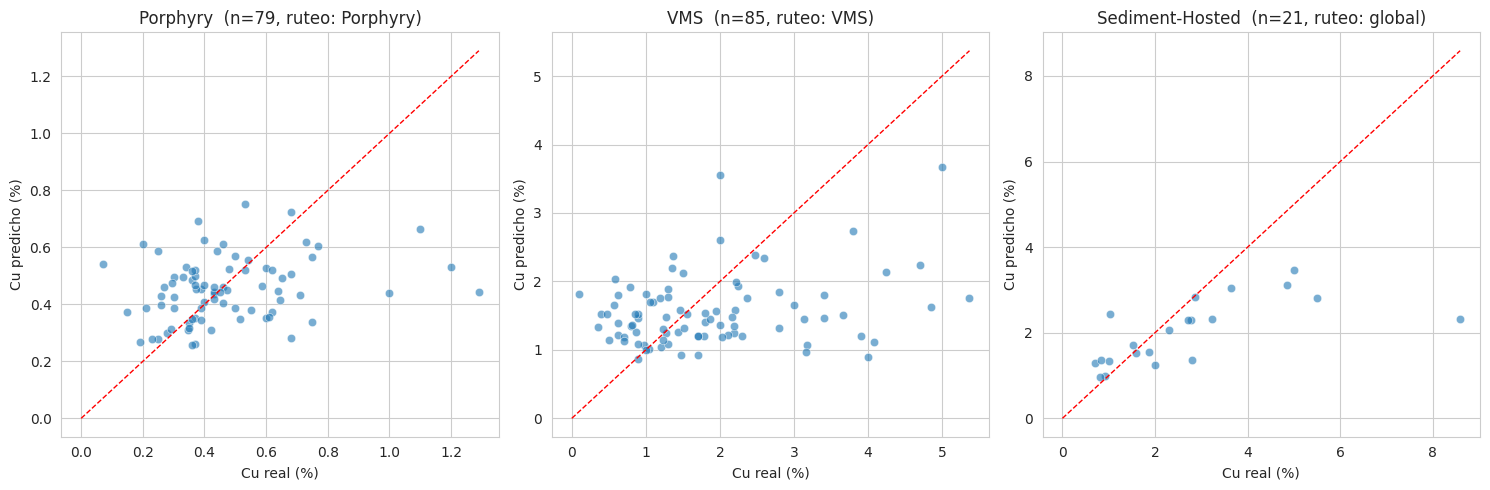

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, d in zip(axes, ["Porphyry", "VMS", "Sediment-Hosted"]):
    m = (g_test == d).values
    if m.sum() == 0:
        continue
    ax.scatter(y_test[m], y_pred[m], alpha=0.6, edgecolor="white", linewidth=0.5)
    lim = max(y_test[m].max(), y_pred[m].max())
    ax.plot([0, lim], [0, lim], "r--", linewidth=1)
    ax.set_xlabel("Cu real (%)")
    ax.set_ylabel("Cu predicho (%)")
    ruteo = hybrid.route(pd.Series([d])).iloc[0]
    ax.set_title(f"{d}  (n={m.sum()}, ruteo: {ruteo})")
plt.tight_layout()
plt.show()